In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/hull-tactical-market-prediction/train.csv
/kaggle/input/hull-tactical-market-prediction/test.csv
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/default_inference_server.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/default_gateway.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/__init__.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/core/templates.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/core/base_gateway.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/core/relay.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/core/kaggle_evaluation.proto
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/core/__init__.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/core/generated/kaggle_evaluation_pb2.py
/kaggle/input/hull-tactical-market-prediction/kaggle_evaluation/core/generated/kaggle_evaluation_pb2_grpc.py
/kaggl

In [2]:
import pandas as pd
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler

# 1. Load + Prepare Data
df = pd.read_csv('/kaggle/input/hull-tactical-market-prediction/train.csv')
TARGET_COL = 'market_forward_excess_returns'
df['target'] = df[TARGET_COL].shift(-1)

# Feature engineering: lag features + rolling stats
for lag in [1, 2, 3, 5]:
    df[f'lag_{lag}'] = df['target'].shift(lag)

df['rolling_mean_5'] = df['target'].rolling(5).mean()
df['rolling_std_5'] = df['target'].rolling(5).std()

# Drop missing values after lags
df_cleaned = df.dropna().reset_index(drop=True)
df_cleaned

,date_id,D1,D2,D3,D4,D5,D6,D7,D8,D9,...,forward_returns,risk_free_rate,market_forward_excess_returns,target,lag_1,lag_2,lag_3,lag_5,rolling_mean_5,rolling_std_5
0,6969,0,0,0,0,0,-1,0,0,0,...,0.001145,0.000040,0.000797,0.004390,0.000797,-0.000306,0.001989,-0.003932,0.000838,0.002627
1,6970,0,0,0,0,0,0,0,1,0,...,0.004738,0.000040,0.004390,0.005669,0.004390,0.000797,-0.000306,-0.002678,0.002508,0.002482
2,6971,0,0,0,0,1,0,0,1,0,...,0.006016,0.000040,0.005669,0.001067,0.005669,0.004390,0.000797,0.001989,0.002323,0.002563
3,6972,0,0,0,0,1,0,1,1,0,...,0.001414,0.000039,0.001067,-0.007529,0.001067,0.005669,0.004390,-0.000306,0.000879,0.005148
4,6973,0,0,0,0,1,0,0,0,1,...,-0.007182,0.000039,-0.007529,0.003067,-0.007529,0.001067,0.005669,0.000797,0.001333,0.005238
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015,8984,0,0,0,0,0,0,1,0,1,...,-0.002896,0.000159,-0.003365,0.001990,-0.003365,0.007887,0.004949,-0.006437,0.000716,0.006355
2016,8985,0,0,0,0,0,0,0,0,0,...,0.002457,0.000155,0.001990,0.001845,0.001990,-0.003365,0.007887,-0.007882,0.002661,0.004183
2017,8986,0,0,0,0,0,0,0,0,0,...,0.002312,0.000156,0.001845,0.002424,0.001845,0.001990,-0.003365,0.004949,0.002156,0.003985
2018,8987,0,0,1,0,0,0,0,0,0,...,0.002891,0.000156,0.002424,0.007843,0.002424,0.001845,0.001990,0.007887,0.002147,0.003969


In [3]:
# 2. Walk-Forward Validation Setup
W_train = 1000
start_test_index = W_train

DROP_COLS = ['date_id', TARGET_COL, 'target', 'risk_free_rate']

all_predictions = []
all_true_returns = []

# Define stronger XGBRegressor
xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

In [4]:
# 3. Setup LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.optimizers import Adam

LSTM_LOOKBACK = 5

# Helper to prep data for LSTM
def prep_lstm_data(X_data, Y_data, lookback=5):
    scaler = MinMaxScaler(feature_range=(-1, 1))
    X_scaled = scaler.fit_transform(X_data)
    X_3d = np.array([X_scaled[i-lookback:i] for i in range(lookback, len(X_scaled))])
    Y_aligned = Y_data.iloc[lookback:].values
    return X_3d, Y_aligned, scaler

# Build LSTM
lstm_model = Sequential([
    Input(shape=(LSTM_LOOKBACK, df_cleaned.drop(columns=DROP_COLS, errors='ignore').shape[1])),
    LSTM(units=32, return_sequences=False),
    Dense(units=1)
])
lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

print(f"Total rows after cleaning: {len(df_cleaned)}")
print(f"Starting WFW at index: {start_test_index}")

2025-10-03 04:21:47.709375: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759465307.939566      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759465308.008801      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Total rows after cleaning: 2020
Starting WFW at index: 1000


2025-10-03 04:22:01.576734: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [5]:
# 4. Walk-Forward Loop
for i in range(start_test_index, len(df_cleaned)):
    train_data = df_cleaned.iloc[i - W_train : i]
    test_data = df_cleaned.iloc[i : i + 1]

    X_train = train_data.drop(columns=DROP_COLS, errors='ignore')
    Y_train = train_data['target']
    X_test = test_data.drop(columns=DROP_COLS, errors='ignore')

    # --- A. Train XGBoost ---
    xgb_model.fit(X_train, Y_train)
    pred_xgb = xgb_model.predict(X_test)[0]

    # --- B. Train LSTM (rolling retrain with scaler update) ---
    X_lstm_train, Y_lstm_train, scaler = prep_lstm_data(X_train, Y_train, lookback=LSTM_LOOKBACK)
    lstm_model.fit(X_lstm_train, Y_lstm_train, epochs=5, batch_size=16, verbose=0)

    # Prepare test sample for LSTM
    if i > LSTM_LOOKBACK:
        X_test_lstm_input = df_cleaned.iloc[i - LSTM_LOOKBACK : i].drop(columns=DROP_COLS, errors='ignore')
        X_test_scaled = scaler.transform(X_test_lstm_input)
        X_test_3d = X_test_scaled[np.newaxis, :, :]
        pred_lstm = lstm_model.predict(X_test_3d, verbose=0)[0][0]
    else:
        pred_lstm = 0.0

    # --- C. Ensemble Prediction ---
    ensemble_pred = 0.6 * pred_xgb + 0.4 * pred_lstm

    all_predictions.append(ensemble_pred)
    all_true_returns.append(test_data['target'].values[0])

    if i % 200 == 0:
        print(f"Completed day {i} / {len(df_cleaned)}")

print("Walk-Forward Validation Complete.")

Completed day 1000 / 2020
Completed day 1200 / 2020
Completed day 1400 / 2020
Completed day 1600 / 2020
Completed day 1800 / 2020
Completed day 2000 / 2020
Walk-Forward Validation Complete.


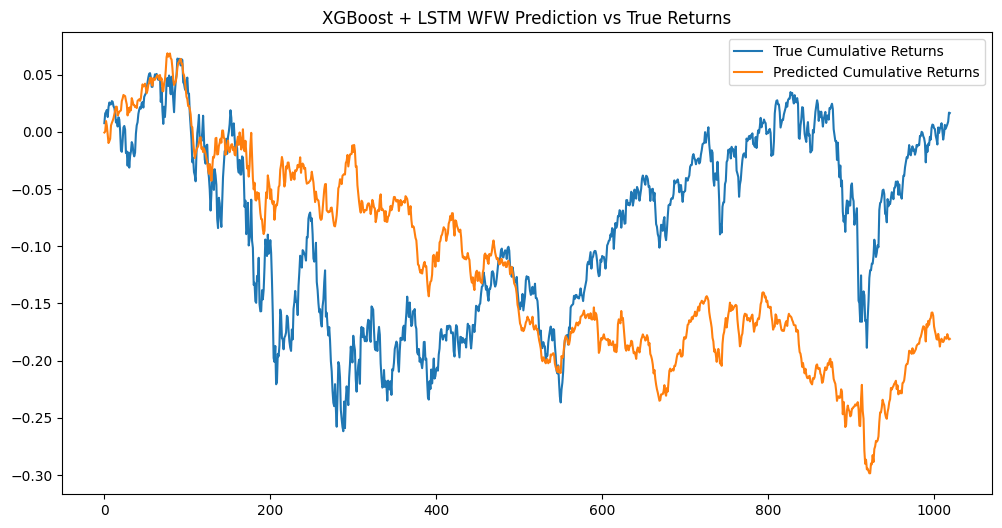

Mean Squared Error: 0.000099
R^2 Score: 0.136678
--- Naive Baseline ---
Naive MSE: 0.000232
Naive R^2: -1.013344


In [6]:
# 5. Evaluate
from matplotlib import pyplot as plt

preds = np.array(all_predictions)
true_vals = np.array(all_true_returns)

cumulative_true = np.cumsum(true_vals)
cumulative_pred = np.cumsum(preds)

plt.figure(figsize=(12,6))
plt.plot(cumulative_true, label="True Cumulative Returns")
plt.plot(cumulative_pred, label="Predicted Cumulative Returns")
plt.legend()
plt.title("XGBoost + LSTM WFW Prediction vs True Returns")
plt.show()

mse = mean_squared_error(true_vals, preds)
r2 = r2_score(true_vals, preds)

print(f"Mean Squared Error: {mse:.6f}")
print(f"R^2 Score: {r2:.6f}")

# Naive Baseline (Lag-1)
naive_preds = df_cleaned['lag_1'].iloc[start_test_index:].values
naive_true = df_cleaned['target'].iloc[start_test_index:].values

naive_mse = mean_squared_error(naive_true, naive_preds)
naive_r2 = r2_score(naive_true, naive_preds)

print("--- Naive Baseline ---")
print(f"Naive MSE: {naive_mse:.6f}")
print(f"Naive R^2: {naive_r2:.6f}")